#Predictive Maintenance Modelling Comparing LSTM, Random Forest, Gradient Boosting, XGBoosting to Forecast RUL Metrics of NASA Turbofan Jet Engines

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Import Data
- Set column names prior to avoid losing first row of data
- Groupby the unit number to find the max time in cycles per engine
- Calculate RUL for each row as: the maximum `time in cycles` value for that unit number (its final/failure cycle) minus the current `time in cycles`.
- Set an upper limit for the RUL value (typically 125 or 130)

In [2]:
import pandas as pd

column_names = ['unit number', 'time in cycles', 'operational setting 1',
              'operational setting 2', 'operational setting 3', 'sensor measurement 1'
              ,'sensor measurement 2', 'sensor measurement 3', 'sensor measurement 4'
              , 'sensor measurement 5', 'sensor measurement 6', 'sensor measurement 7'
              , 'sensor measurement 8', 'sensor measurement 9', 'sensor measurement 10'
              , 'sensor measurement 11', 'sensor measurement 12', 'sensor measurement 13'
              , 'sensor measurement 14', 'sensor measurement 15', 'sensor measurement 16'
              , 'sensor measurement 17', 'sensor measurement 18', 'sensor measurement 19'
              , 'sensor measurement 20', 'sensor measurement 21']

df = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=column_names)

max_cycle = df.groupby('unit number')['time in cycles'].max()
df['RUL'] = df['unit number'].map(max_cycle) - df['time in cycles']
df['RUL'] = df['RUL'].clip(upper=125)



df.head()

,unit number,time in cycles,operational setting 1,operational setting 2,operational setting 3,sensor measurement 1,sensor measurement 2,sensor measurement 3,sensor measurement 4,sensor measurement 5,...,sensor measurement 13,sensor measurement 14,sensor measurement 15,sensor measurement 16,sensor measurement 17,sensor measurement 18,sensor measurement 19,sensor measurement 20,sensor measurement 21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


Create correlation matrix to assess most relevent feautures (in relation to RUL)

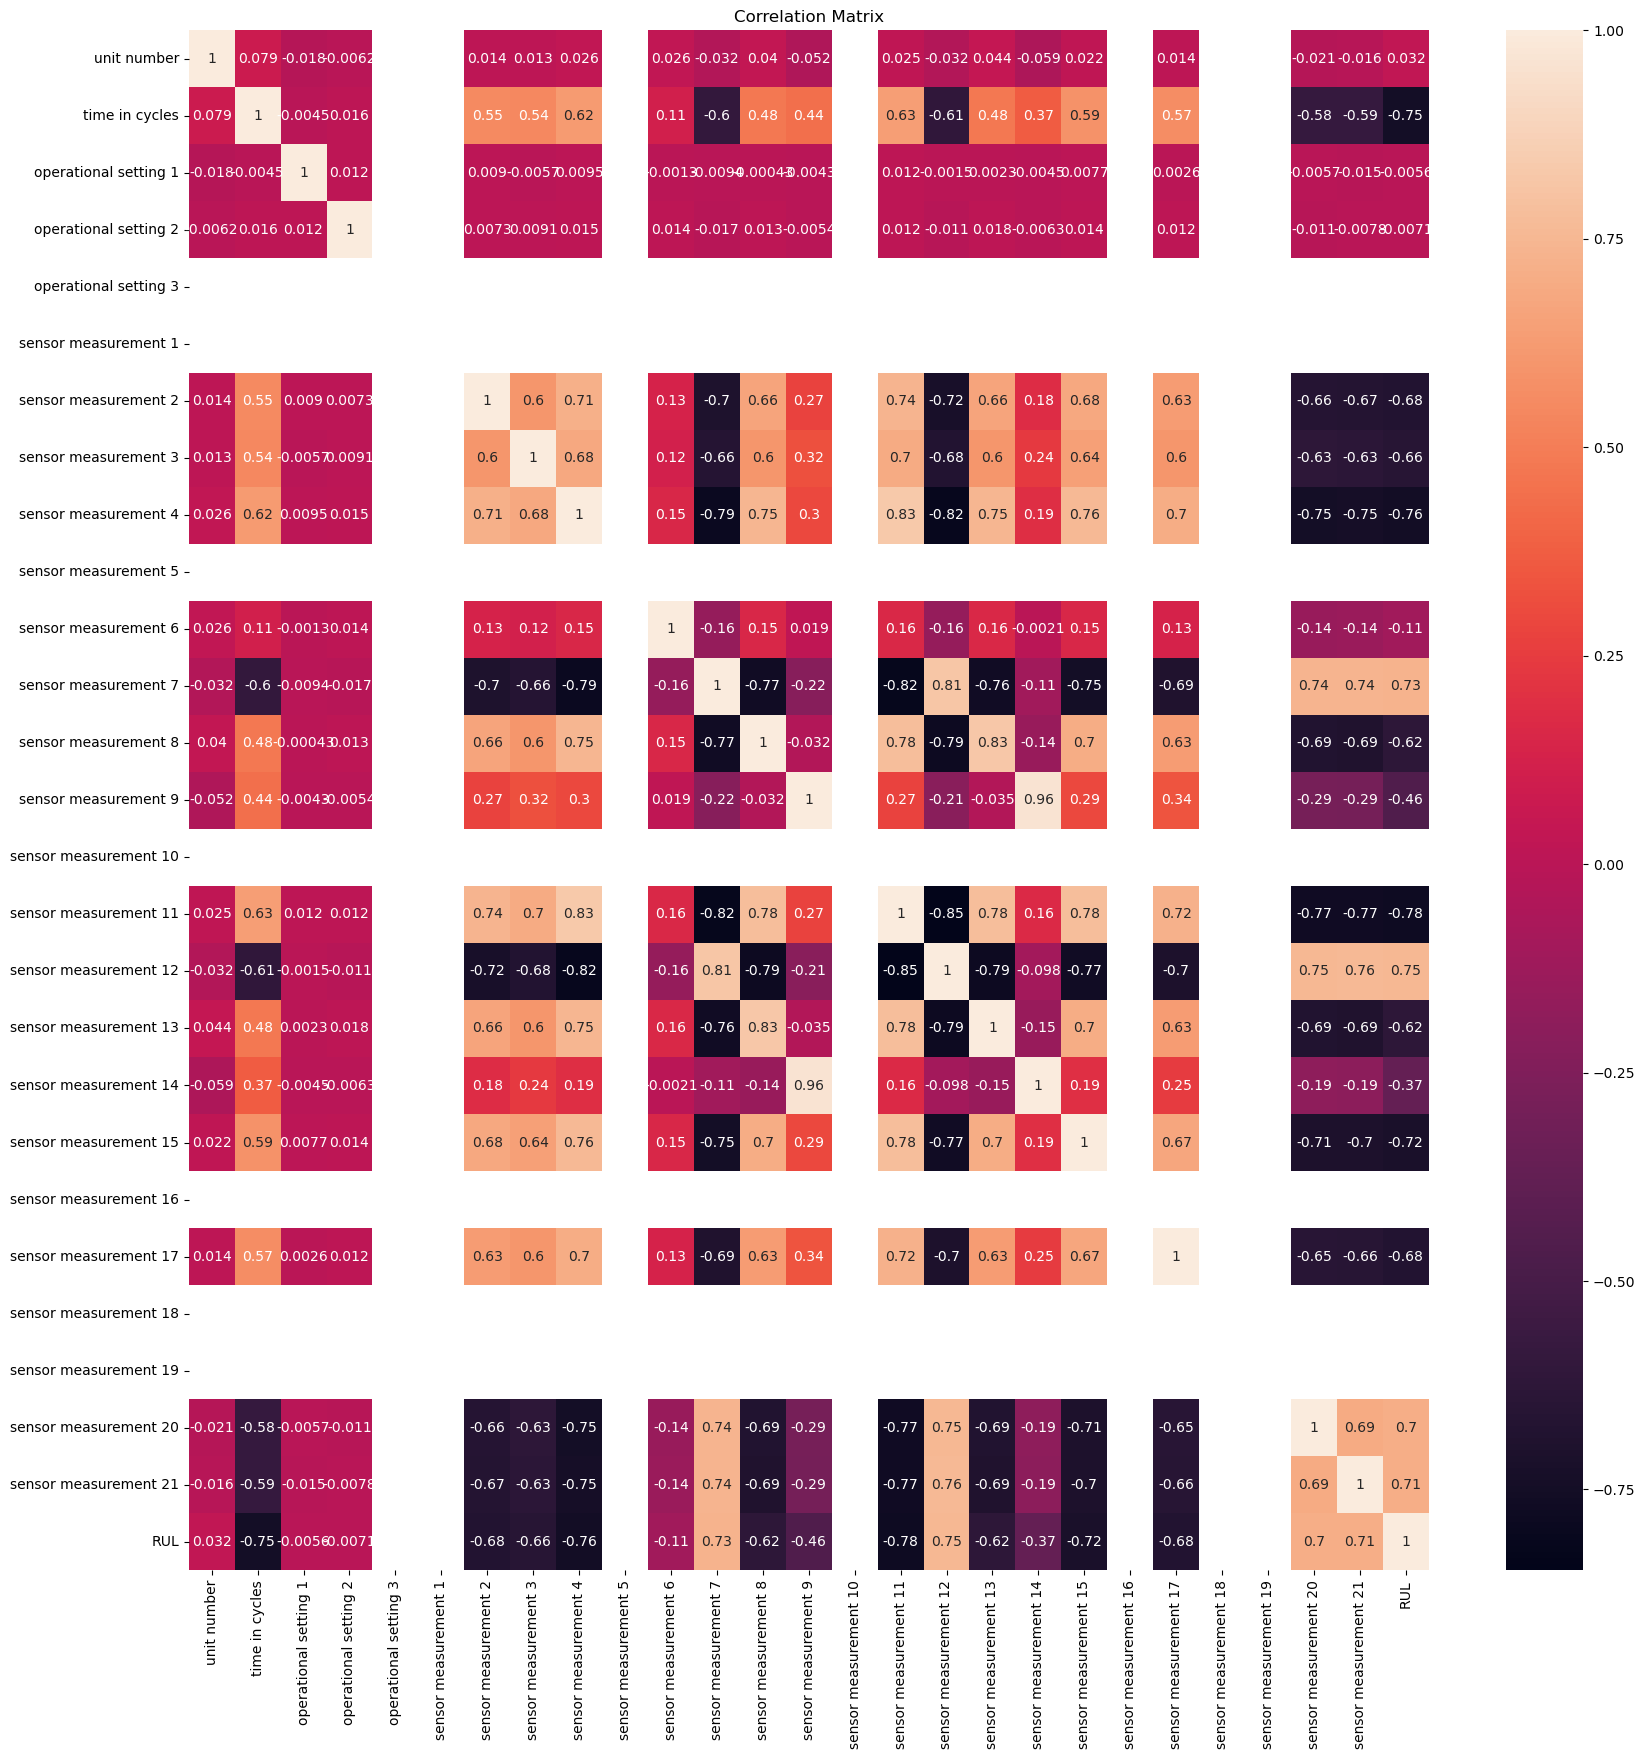

In [3]:
import seaborn as sns

corr_matrix = df.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, cmap='rocket')
plt.title('Correlation Matrix')
plt.show()

In [4]:
relevant_features = []
relevant_values = []
target = abs(df.corr().loc['RUL'])

for label, value in target.items():
  if value > 0.04 and label != 'RUL' and label != 'time in cycles':
    relevant_features.append(label)
    relevant_values.append(value)

print(relevant_values)
print(relevant_features)
print(target)

[0.6784582844138087, 0.655030388486991, 0.7571567446044734, 0.10828884295431779, 0.7330210310750626, 0.6245680273995373, 0.46215091781290757, 0.775229821871158, 0.7488698691357298, 0.6240343312687711, 0.3697525579251208, 0.7208584828528034, 0.6808294987192683, 0.7046255559265816, 0.7073341478068336]
['sensor measurement 2', 'sensor measurement 3', 'sensor measurement 4', 'sensor measurement 6', 'sensor measurement 7', 'sensor measurement 8', 'sensor measurement 9', 'sensor measurement 11', 'sensor measurement 12', 'sensor measurement 13', 'sensor measurement 14', 'sensor measurement 15', 'sensor measurement 17', 'sensor measurement 20', 'sensor measurement 21']
unit number              0.031546
time in cycles           0.746939
operational setting 1    0.005556
operational setting 2    0.007091
operational setting 3         NaN
sensor measurement 1          NaN
sensor measurement 2     0.678458
sensor measurement 3     0.655030
sensor measurement 4     0.757157
sensor measurement 5    

Create new dataframe with relevant features only

In [5]:
data = df[relevant_features]
data.head()

,sensor measurement 2,sensor measurement 3,sensor measurement 4,sensor measurement 6,sensor measurement 7,sensor measurement 8,sensor measurement 9,sensor measurement 11,sensor measurement 12,sensor measurement 13,sensor measurement 14,sensor measurement 15,sensor measurement 17,sensor measurement 20,sensor measurement 21
0,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


Create the random forest model while using GridSearchCV to find optimal hyperparamters
Compare model results using GridSeachCV and RandomizedSearchCV

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, GroupKFold

param_grid = {
    'n_estimators': [50, 100, 250],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 3, 4],
}
groups = df['unit number']
gkf = GroupKFold(n_splits=5)

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=gkf,
    n_jobs=-1,
    verbose=1,
    scoring='neg_root_mean_squared_error'
)

X = data
y = df['RUL']

grid_search.fit(X, y, groups=groups)



Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=GroupKFold(n_splits=5),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, 20],
                         'min_samples_leaf': [2, 3, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 250]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [8]:
prod = grid_search.best_estimator_

In [9]:
prod.score(X, y)

0.9117477171664513

In [10]:
test_df = pd.read_csv('test_FD001.txt', sep=r'\s+', header=None, names=column_names)
test_df.head()

,unit number,time in cycles,operational setting 1,operational setting 2,operational setting 3,sensor measurement 1,sensor measurement 2,sensor measurement 3,sensor measurement 4,sensor measurement 5,...,sensor measurement 12,sensor measurement 13,sensor measurement 14,sensor measurement 15,sensor measurement 16,sensor measurement 17,sensor measurement 18,sensor measurement 19,sensor measurement 20,sensor measurement 21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [11]:
test_last = test_df.groupby('unit number').last().reset_index()


In [12]:
rul_test_df = pd.read_csv('RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])
rul_test_df['RUL'] = rul_test_df['RUL'].clip(upper=125)

rul_test_df.head()

,RUL
0,112
1,98
2,69
3,82
4,91


In [13]:
X_test = test_last[relevant_features]
y_true = rul_test_df['RUL']

y_pred = prod.predict(X_test)

Test results (mean absolute error + root mean square error)
- Optimal values for Random Forest Model -> RMSE: 17 - 22 | MAE: 13 - 17

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 12.32
RMSE: 17.33


In [15]:
prod.score(X_test, y_true)

0.8130581941179682

MAE: 14.56
RMSE: 19.07
Decent results

Results using RandomizedSearchCV

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from scipy.stats import randint as sp_randint

param_grid = {
    'n_estimators': sp_randint(50, 500),
    'max_depth': sp_randint(5, 30),
    'min_samples_split': sp_randint(2, 11),
    'min_samples_leaf': sp_randint(1, 11)
}
groups = df['unit number']
gkf = GroupKFold(n_splits=5)

random_search = RandomizedSearchCV(
  RandomForestRegressor(random_state=42),
  param_distributions=param_grid,
  cv = gkf,
  n_jobs=-1,
  verbose=1,
  scoring='neg_root_mean_squared_error',
  n_iter=100
)

random_search.fit(X, y, groups=groups)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=GroupKFold(n_splits=5),
                   estimator=RandomForestRegressor(random_state=42), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000022B5F573110>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000022B5F6C9190>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000022B5F6C9B80>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000022B5F5A2C30>},
                   scoring='neg_root_mean_squared_error', verbose=1)

In [17]:
final_prod = random_search.best_estimator_
final_prod.score(X, y)

0.8808845791086932

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = rul_test_df['RUL']
y_pred = final_prod.predict(X_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')


MAE: 12.33
RMSE: 17.43


In [19]:
final_prod.score(X_test, y_true)

0.8108524231541537

XGBoost

In [20]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [21]:
from sklearn.model_selection import GridSearchCV, GroupKFold
X = data
y = df['RUL']
param_grid = {
    'n_estimators': [100, 250, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
}

groups = df['unit number']
gkf = GroupKFold(n_splits=5)

grid_search_xgb = GridSearchCV(
    xgb.XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=gkf,
    n_jobs=-1,
    verbose=1,
    scoring='r2'
)

grid_search_xgb.fit(X, y, groups=groups)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=GroupKFold(n_splits=5),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interact...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.9],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 250, 400],
                         'subsample': [0.7, 0.9]},
             scoring='r2', verbose=1)

In [22]:
xgb_prod = grid_search_xgb.best_estimator_
xgb_prod.score(X, y)

0.8559560775756836

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = rul_test_df['RUL']
y_pred = xgb_prod.predict(X_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

MAE: 11.89
RMSE: 16.89


In [24]:
xgb_prod.score(X_test, y_true)

0.822399377822876

Feature Engineering:
- Sliding Window: Since this is a time series, currently the XG Boost model can't look at the history of the sensor data because these model look at the data row by row (thus no history). By finding this window and calculating the average (mean, standard deviation, etc...) across the window we can pack the history into a single row.
- Essentially, we are capturing trends/changes in the data over time rather then single points.  

In [68]:
data.head()

,sensor measurement 2,sensor measurement 3,sensor measurement 4,sensor measurement 6,sensor measurement 7,sensor measurement 8,sensor measurement 9,sensor measurement 11,sensor measurement 12,sensor measurement 13,sensor measurement 14,sensor measurement 15,sensor measurement 17,sensor measurement 20,sensor measurement 21
0,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


In [62]:
feature_cols_for_rolling = [c for c in relevant_features if c not in ['unit number', 'RUL']]

eng_df = df.copy()
window_size = 20

for col in feature_cols_for_rolling:
    eng_df[f'{col}_rolling_mean'] = eng_df.groupby('unit number')[col].transform(lambda x: x.rolling(window=window_size, min_periods=1).mean())
    eng_df[f'{col}_rolling_std']  = eng_df.groupby('unit number')[col].transform(lambda x: x.rolling(window=window_size, min_periods=1).std().fillna(0))
    eng_df[f'{col}_trend'] = eng_df[col] - eng_df[f'{col}_rolling_mean']

test_eng_df = test_df.copy()
for col in feature_cols_for_rolling:
    test_eng_df[f'{col}_rolling_mean'] = test_eng_df.groupby('unit number')[col].transform(lambda x: x.rolling(window=window_size, min_periods=1).mean())
    test_eng_df[f'{col}_rolling_std']  = test_eng_df.groupby('unit number')[col].transform(lambda x: x.rolling(window=window_size, min_periods=1).std().fillna(0))
    test_eng_df[f'{col}_trend'] = test_eng_df[col] - test_eng_df[f'{col}_rolling_mean']

test_last_eng = test_eng_df.groupby('unit number').last().reset_index()

final_training_features = ['time in cycles'] + feature_cols_for_rolling + \
                          [f'{col}_rolling_mean' for col in feature_cols_for_rolling] + \
                          [f'{col}_rolling_std' for col in feature_cols_for_rolling] + \
                          [f'{col}_trend' for col in feature_cols_for_rolling]

X = eng_df[final_training_features]
y = eng_df['RUL']

X_test_fe = test_last_eng[final_training_features]
y_true = rul_test_df['RUL']

MAX_RUL = 125
y_clipped = y.clip(upper=MAX_RUL)

param_grid = {
    'n_estimators': [250, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 5, 6, 7],
    'min_child_weight': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 5.0, 10.0]
}

groups = df['unit number']
gkf = GroupKFold(n_splits=4)

grid_search_xgb_fe = RandomizedSearchCV(
    xgb.XGBRegressor(
        random_state=42,
        tree_method='hist'
    ),
    param_distributions=param_grid,
    n_iter=50,
    cv=gkf,
    n_jobs=-1,
    verbose=1,
    scoring='r2',
    random_state=42
)

grid_search_xgb_fe.fit(X, y_clipped, groups=groups)

Fitting 4 folds for each of 50 candidates, totalling 200 fits


RandomizedSearchCV(cv=GroupKFold(n_splits=4),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          in...
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 5, 6, 7],
                                        'min_child_weight': [3, 5, 7],
                                        'n_estimators': [250, 500, 800],
                                        'reg_alpha': [0, 0.1, 1.0],
                                        'reg_lambda': [1.0, 5.0, 10.0],
                                        'subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='r2', verbose=1)

In [63]:

xgb_fe_prod = grid_search_xgb_fe.best_estimator_

y_pred = xgb_fe_prod.predict(X_test_fe)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f'Training Score (R2): {xgb_fe_prod.score(X, y):.4f}')
print(f'Test Score (R2): {xgb_fe_prod.score(X_test_fe, y_true):.4f}')
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

Training Score (R2): 0.9073
Test Score (R2): 0.8312
MAE: 11.86
RMSE: 16.47


LSTM

In [72]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [76]:
class CMAPSSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class RULLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(RULLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        out, _ = self.lstm(x, (h0, c0))


        out = self.fc1(out[:, -1, :])
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)

        return out.squeeze()

def create_sequences(df, feature_cols, target_col, window_size):

    X_seq, y_seq = [], []

    for unit_id, group in df.groupby('unit number'):
        data_matrix = group[feature_cols].values
        target_vector = group[target_col].values

        if len(data_matrix) >= window_size:
            for i in range(len(data_matrix) - window_size + 1):
                X_seq.append(data_matrix[i : i + window_size])

                y_seq.append(target_vector[i + window_size - 1])

    return np.array(X_seq), np.array(y_seq)

def prepare_data_for_lstm(train_df, test_df, rul_test_df, feature_cols, window_size=30):

    MAX_RUL = 125
    train_df['RUL_clipped'] = train_df['RUL'].clip(upper=MAX_RUL)
    rul_test_df['RUL_clipped'] = rul_test_df['RUL'].clip(upper=MAX_RUL)

    scaler = StandardScaler()
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df[feature_cols] = scaler.transform(test_df[feature_cols])

    print("Creating training sequences...")
    X_train_seq, y_train_seq = create_sequences(train_df, feature_cols, 'RUL_clipped', window_size)
    print(f"Training sequences shape: X={X_train_seq.shape}, y={y_train_seq.shape}")

    print("Creating test sequences...")
    X_test_seq = []
    y_test_seq = []

    unit_ids = test_df['unit number'].unique()
    for i, unit_id in enumerate(unit_ids):
        group = test_df[test_df['unit number'] == unit_id]
        data_matrix = group[feature_cols].values

        if len(data_matrix) < window_size:
            padding = np.zeros((window_size - len(data_matrix), len(feature_cols)))
            padded_data = np.vstack((padding, data_matrix))
            X_test_seq.append(padded_data)
        else:
            X_test_seq.append(data_matrix[-window_size:])

        y_test_seq.append(rul_test_df.iloc[i]['RUL_clipped'])

    X_test_seq = np.array(X_test_seq)
    y_test_seq = np.array(y_test_seq)
    print(f"Test sequences shape: X={X_test_seq.shape}, y={y_test_seq.shape}")

    return X_train_seq, y_train_seq, X_test_seq, y_test_seq

def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=50, patience=10):
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
      train_plot_loss, test_plot_loss = [], []
      model.train()
      train_loss = 0.0
      for inputs, targets in train_loader:
          inputs, targets = inputs.to(device), targets.to(device)

          optimizer.zero_grad()
          outputs = model(inputs)
          loss = criterion(outputs, targets)
          loss.backward()
          optimizer.step()

          train_loss += loss.item() * inputs.size(0)

      train_loss /= len(train_loader.dataset)
      train_plot_loss.append(train_loss)

      model.eval()
      val_loss = 0.0
      with torch.no_grad():
          for inputs, targets in test_loader:
              inputs, targets = inputs.to(device), targets.to(device)
              outputs = model(inputs)
              loss = criterion(outputs, targets)
              val_loss += loss.item() * inputs.size(0)

      val_loss /= len(test_loader.dataset)
      test_plot_loss.append(val_loss)

      print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

      if val_loss < best_val_loss:
          best_val_loss = val_loss
          patience_counter = 0
          torch.save(model.state_dict(), 'best_lstm_model.pth')
      else:
          patience_counter += 1
          if patience_counter >= patience:
              print(f"Early stopping triggered at epoch {epoch+1}")
              break
features_to_use = relevant_features


window_size = 30
X_train, y_train, X_test, y_test = prepare_data_for_lstm(
    train_df=df.copy(),
    test_df=test_df.copy(),
    rul_test_df=rul_test_df.copy(),
    feature_cols=features_to_use,
    window_size=window_size
)

batch_size = 64
train_dataset = CMAPSSDataset(X_train, y_train)
test_dataset = CMAPSSDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

input_size = X_train.shape[2]
model = RULLSTM(input_size=input_size, hidden_size=64, num_layers=2, dropout=0.2).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\nStarting Training...")
train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=100, patience=15)

print("\nEvaluating Best Model...")
model.load_state_dict(torch.load('best_lstm_model.pth'))
model.eval()

all_preds = []
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        all_preds.extend(outputs.cpu().numpy())

y_pred = np.array(all_preds)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2}')
print(f"LSTM Test MAE:  {mae:.2f}")
print(f"LSTM Test RMSE: {rmse:.2f}")

Creating training sequences...
Training sequences shape: X=(17731, 30, 15), y=(17731,)
Creating test sequences...
Test sequences shape: X=(100, 30, 15), y=(100,)

Starting Training...
Epoch [1/100], Train Loss: 3367.6355, Val Loss: 292.4542
Epoch [2/100], Train Loss: 371.7946, Val Loss: 236.4033
Epoch [3/100], Train Loss: 293.3726, Val Loss: 188.4200
Epoch [4/100], Train Loss: 275.8787, Val Loss: 268.0653
Epoch [5/100], Train Loss: 257.3539, Val Loss: 210.0001
Epoch [6/100], Train Loss: 259.4536, Val Loss: 226.6473
Epoch [7/100], Train Loss: 244.1418, Val Loss: 198.7609
Epoch [8/100], Train Loss: 235.7102, Val Loss: 195.1970
Epoch [9/100], Train Loss: 231.7950, Val Loss: 214.8505
Epoch [10/100], Train Loss: 219.0264, Val Loss: 221.1970
Epoch [11/100], Train Loss: 222.4356, Val Loss: 262.0115
Epoch [12/100], Train Loss: 211.3196, Val Loss: 217.2060
Epoch [13/100], Train Loss: 208.4800, Val Loss: 225.1884
Epoch [14/100], Train Loss: 204.6150, Val Loss: 277.4674
Epoch [15/100], Train Loss

plt.plot(x, y1, label='Line 1', color='blue', linestyle='-')

# 3. Plot the second line on the same axes
plt.plot(x, y2, label='Line 2', color='red', linestyle='--')

Combining LSTM + XGBoost Trees

--- 50/50 Ensemble Baseline ---
R2:   0.8891
RMSE: 13.34
MAE:  9.85

--- Optimal Ensemble Weights ---
XGBoost Weight: 0.144
LSTM Weight:    0.856



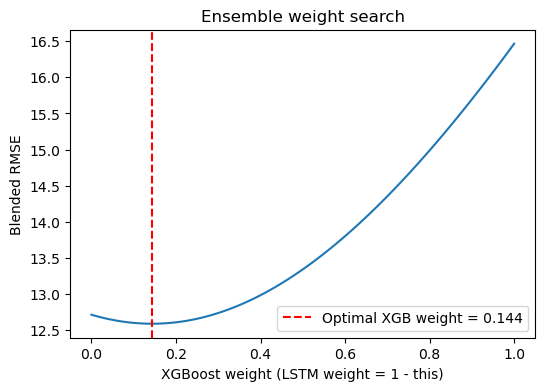

--- Final Optimized Ensemble Performance ---
R2:   0.9013
RMSE: 12.59
MAE:  9.40


In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import minimize_scalar

xgb_fe_prod = grid_search_xgb_fe.best_estimator_
y_pred_xgb = xgb_fe_prod.predict(X_test_fe)

model.eval()
all_lstm_preds = []
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        all_lstm_preds.extend(outputs.cpu().numpy())

y_pred_lstm = np.array(all_lstm_preds)

y_true_np = y_true.values if isinstance(y_true, pd.Series) else y_true



y_pred_5050 = (0.5 * y_pred_xgb) + (0.5 * y_pred_lstm)

print("--- 50/50 Ensemble Baseline ---")
print(f"R2:   {r2_score(y_true_np, y_pred_5050):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true_np, y_pred_5050)):.2f}")
print(f"MAE:  {mean_absolute_error(y_true_np, y_pred_5050):.2f}\n")


def ensemble_loss(w, pred_model1, pred_model2, true_y):
    blended_pred = (w * pred_model1) + ((1.0 - w) * pred_model2)
    return np.sqrt(mean_squared_error(true_y, blended_pred))

result = minimize_scalar(
    ensemble_loss,
    bounds=(0.0, 1.0),
    method='bounded',
    args=(y_pred_xgb, y_pred_lstm, y_true_np)
)

optimal_xgb_weight = result.x
optimal_lstm_weight = 1.0 - optimal_xgb_weight

print("--- Optimal Ensemble Weights ---")
print(f"XGBoost Weight: {optimal_xgb_weight:.3f}")
print(f"LSTM Weight:    {optimal_lstm_weight:.3f}\n")

weights = np.linspace(0, 1, 101)
losses = [ensemble_loss(w, y_pred_xgb, y_pred_lstm, y_true_np) for w in weights]

plt.figure(figsize=(6, 4))
plt.plot(weights, losses)
plt.axvline(optimal_xgb_weight, color='r', linestyle='--', label=f'Optimal XGB weight = {optimal_xgb_weight:.3f}')
plt.xlabel('XGBoost weight (LSTM weight = 1 - this)')
plt.ylabel('Blended RMSE')
plt.title('Ensemble weight search')
plt.legend()
plt.show()

y_pred_optimal = (optimal_xgb_weight * y_pred_xgb) + (optimal_lstm_weight * y_pred_lstm)

print("--- Final Optimized Ensemble Performance ---")
print(f"R2:   {r2_score(y_true_np, y_pred_optimal):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true_np, y_pred_optimal)):.2f}")
print(f"MAE:  {mean_absolute_error(y_true_np, y_pred_optimal):.2f}")

# Final Performance Data:

### Random Forest (GridSearchCV)
MAE: 12.32 | RMSE: 17.33 | R2: 0.813

### Random Forest (RandomizedSearchCV)
MAE: 12.33 | RMSE: 17.43 | R2 0.810

### XGBoost (raw features)
MAE: 11.89 | RMSE: 16.89 | R2 0.822

### XGBoost (+ rolling/trend features)
MAE: 11.86 | RMSE: 16.47 | R2: 0.831

### LSTM (30-cycle sequence window)
MAE: 9.54 | RMSE: 12.72 | R2: 0.899
### Ensemble (LSTM + XGBoost 50/50 weighting)
MAE: 9.85 | RMSE: 13.34 | R2: 0.889

### Ensemble (optimized weighting)
MAE: 9.40 | RMSE: 12.59 | R2: 0.901

